<a href="https://colab.research.google.com/github/AHMEDVALL70/ahmed-vall-cv/blob/main/Procurement_Fraud_Detection_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ البيانات والنموذج جاهزان!
  vendor_name  bid_amount_usd  days_to_submit      status
0    Vendor_A           50000              15      Normal
1    Vendor_B           48000              14      Normal
2    Vendor_C           52000              16      Normal
3    Vendor_D          450000               2  Suspicious
4    Vendor_E           49000              15      Normal
5    Vendor_F           51000              14      Normal
6    Vendor_G           47000              15      Normal
7    Vendor_H          500000               1  Suspicious
8    Vendor_I           53000              16      Normal
9    Vendor_J           46000              14      Normal


/tmp/ipykernel_14372/266689719.py:78: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14372/266689719.py:78: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14372/266689719.py:79: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('fraud_detection_results.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_14372/266689719.py:79: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.savefig('fraud_detection_results.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12

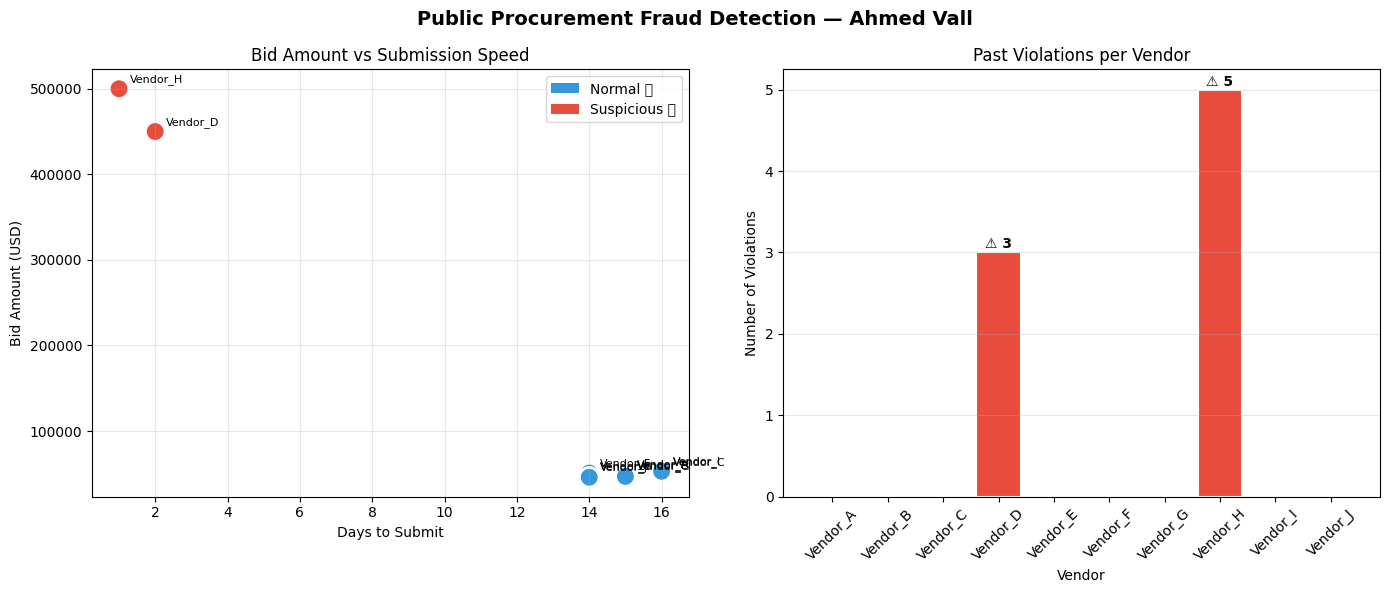

✅ تم حفظ الرسم البياني!


In [3]:
!pip install arabic-reshaper python-bidi -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.ensemble import IsolationForest

# ── البيانات ──
data = {
    'bid_id': range(1, 11),
    'vendor_name': ['Vendor_A', 'Vendor_B', 'Vendor_C', 'Vendor_D', 'Vendor_E',
                   'Vendor_F', 'Vendor_G', 'Vendor_H', 'Vendor_I', 'Vendor_J'],
    'bid_amount_usd': [50000, 48000, 52000, 450000, 49000, 51000, 47000, 500000, 53000, 46000],
    'days_to_submit': [15, 14, 16, 2, 15, 14, 15, 1, 16, 14],
    'past_violations': [0, 0, 0, 3, 0, 0, 0, 5, 0, 0]
}
df = pd.DataFrame(data)

# ── النموذج ──
features = df[['bid_amount_usd', 'days_to_submit', 'past_violations']]
model = IsolationForest(contamination=0.2, random_state=42)
df['anomaly_score'] = model.fit_predict(features)
df['status'] = df['anomaly_score'].map({1: 'Normal', -1: 'Suspicious'})

print("✅ البيانات والنموذج جاهزان!")
print(df[['vendor_name', 'bid_amount_usd', 'days_to_submit', 'status']])

# ── الرسم البياني ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Public Procurement Fraud Detection — Ahmed Vall',
             fontsize=14, fontweight='bold')

# 1️⃣ Scatter Plot
colors = df['status'].map({'Normal': '#3498db', 'Suspicious': '#e74c3c'})
axes[0].scatter(
    df['days_to_submit'],
    df['bid_amount_usd'],
    c=colors, s=200, edgecolors='white', linewidth=2
)
for _, row in df.iterrows():
    axes[0].annotate(
        row['vendor_name'],
        (row['days_to_submit'], row['bid_amount_usd']),
        textcoords="offset points",
        xytext=(8, 5), fontsize=8
    )
axes[0].set_title('Bid Amount vs Submission Speed', fontsize=12)
axes[0].set_xlabel('Days to Submit')
axes[0].set_ylabel('Bid Amount (USD)')
axes[0].grid(True, alpha=0.3)
legend_elements = [
    Patch(facecolor='#3498db', label='Normal ✅'),
    Patch(facecolor='#e74c3c', label='Suspicious 🚨')
]
axes[0].legend(handles=legend_elements)

# 2️⃣ Bar Chart
bar_colors = ['#e74c3c' if s == 'Suspicious' else '#3498db'
              for s in df['status']]
bars = axes[1].bar(df['vendor_name'], df['past_violations'],
                    color=bar_colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Past Violations per Vendor', fontsize=12)
axes[1].set_xlabel('Vendor')
axes[1].set_ylabel('Number of Violations')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, df['past_violations']):
    if val > 0:
        axes[1].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'⚠️ {val}', ha='center',
            fontweight='bold', fontsize=10
        )

plt.tight_layout()
plt.savefig('fraud_detection_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ تم حفظ الرسم البياني!")

In [4]:
from google.colab import files

# تحميل الملفات
files.download('fraud_detection_results.png')
print("✅ تم تحميل الصورة!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ تم تحميل الصورة!
